# Datos Faltantes

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [4]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
397,0.052606,-0.044642,-0.004050,-0.030907,-0.046975,-0.058307,-0.013948,-0.025840,0.036060,0.023775,198.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
174,0.016281,0.050680,0.009961,-0.043542,-0.096510,-0.094632,-0.039719,-0.039493,0.017036,0.007207,151.0
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062,51.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
354,-0.023677,0.050680,0.045529,0.021872,0.109883,0.088873,0.000779,0.034309,0.074191,0.061054,272.0
331,0.081666,0.050680,-0.025607,-0.036656,-0.070367,-0.046407,-0.039719,-0.002592,-0.041176,-0.005220,199.0
61,-0.041840,0.050680,0.004572,-0.053870,-0.044223,-0.027305,-0.080217,0.071210,0.036644,0.019633,144.0
209,0.038076,0.050680,-0.018062,0.066629,-0.051103,-0.016658,-0.076536,0.034309,-0.011897,-0.013504,77.0
405,0.048974,0.050680,0.123131,0.083844,-0.104765,-0.100895,-0.069172,-0.002592,0.036644,-0.030072,281.0


In [5]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [6]:
# Contar valores faltantes por columna
valores_faltantes = data.isnull().sum()
print("Valores faltantes por columna:")
print(valores_faltantes)

Valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
# Imputación simple usando la media para la columna 'bmi'
bmi_original = data['bmi'].copy()

simple_imputer = SimpleImputer(strategy='mean')
data['bmi_imputado_media'] = simple_imputer.fit_transform(data[['bmi']])

print(f"Media usada para imputar: {simple_imputer.statistics_[0]:.5f}")
print(f"Valores faltantes en bmi original: {bmi_original.isnull().sum()}")
print(f"Valores faltantes en bmi imputado: {data['bmi_imputado_media'].isnull().sum()}")
data[['bmi', 'bmi_imputado_media']].head(10)

Media usada para imputar: -0.00020
Valores faltantes en bmi original: 44
Valores faltantes en bmi imputado: 0


,bmi,bmi_imputado_media
0,0.061696,0.061696
1,-0.051474,-0.051474
2,0.044451,0.044451
3,-0.011595,-0.011595
4,-0.036385,-0.036385
5,-0.040696,-0.040696
6,-0.047163,-0.047163
7,-0.001895,-0.001895
8,0.061696,0.061696
9,NaN,-0.000205


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [8]:
# Imputación con KNNImputer en 'bmi' y 'bp'
columnas_numericas = diabetes.data.columns.tolist()  # columnas originales sin 'target'
data_para_knn = data[columnas_numericas].copy()

knn_imputer = KNNImputer(n_neighbors=5)
data_knn = pd.DataFrame(
    knn_imputer.fit_transform(data_para_knn),
    columns=columnas_numericas
)

# Comparación entre imputación simple (media) y KNN para 'bmi' y 'bp'
imputer_media_bp = SimpleImputer(strategy='mean')
bp_media = imputer_media_bp.fit_transform(data[['bp']]).flatten()

comparacion = pd.DataFrame({
    'bmi_original': data['bmi'],
    'bmi_media': data['bmi_imputado_media'],
    'bmi_knn': data_knn['bmi'],
    'bp_original': data['bp'],
    'bp_media': bp_media,
    'bp_knn': data_knn['bp']
})

print("Estadísticas de bmi:")
print(comparacion[['bmi_original', 'bmi_media', 'bmi_knn']].describe())
print("\nEstadísticas de bp:")
print(comparacion[['bp_original', 'bp_media', 'bp_knn']].describe())

# Mostrar solo las filas que originalmente tenían NaN
mask_nan_bmi = data['bmi'].isnull()
print("\nFilas que tenían NaN en bmi (comparación de imputaciones):")
print(comparacion.loc[mask_nan_bmi, ['bmi_media', 'bmi_knn']].head(10))

Estadísticas de bmi:
       bmi_original   bmi_media     bmi_knn
count    398.000000  442.000000  442.000000
mean      -0.000205   -0.000205    0.000008
std        0.046989    0.044583    0.045597
min       -0.089197   -0.089197   -0.089197
25%       -0.035037   -0.030996   -0.033151
50%       -0.007284   -0.000817   -0.006745
75%        0.030440    0.024781    0.030440
max        0.160855    0.160855    0.160855

Estadísticas de bp:
       bp_original    bp_media      bp_knn
count   398.000000  442.000000  442.000000
mean      0.000465    0.000465    0.000237
std       0.048043    0.045583    0.046370
min      -0.112399   -0.112399   -0.112399
25%      -0.033213   -0.033213   -0.033213
50%      -0.005670    0.000465   -0.005670
75%       0.035644    0.028758    0.034391
max       0.132044    0.132044    0.132044

Filas que tenían NaN en bmi (comparación de imputaciones):
    bmi_media   bmi_knn
9   -0.000205  0.072690
30  -0.000205  0.007806
39  -0.000205 -0.024529
55  -0.000205 -0.00

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

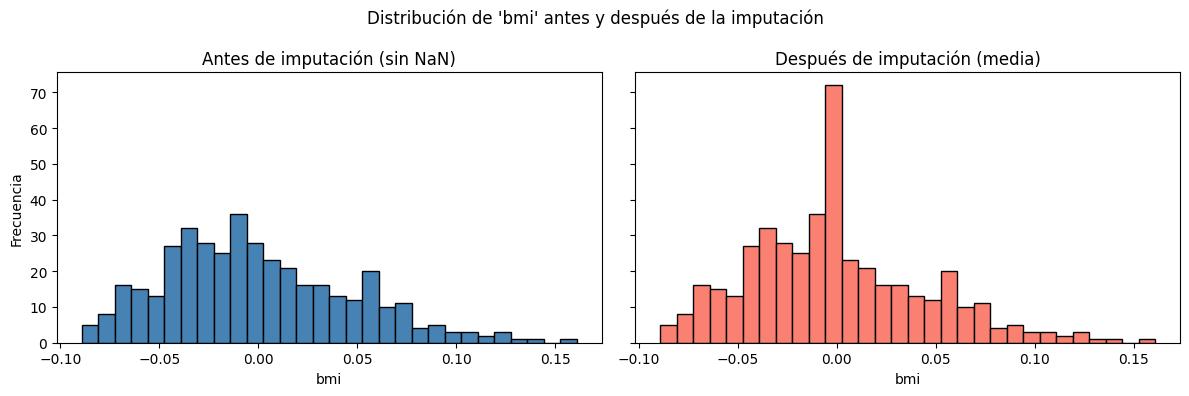

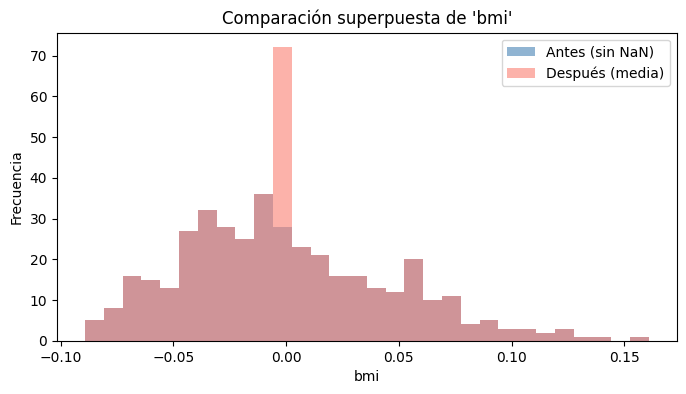

In [9]:
# Histograma comparando 'bmi' antes y después de la imputación
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Antes: solo valores no nulos (los datos originales disponibles)
axes[0].hist(data['bmi'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Antes de imputación (sin NaN)')
axes[0].set_xlabel('bmi')
axes[0].set_ylabel('Frecuencia')

# Después: con valores imputados por la media
axes[1].hist(data['bmi_imputado_media'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Después de imputación (media)')
axes[1].set_xlabel('bmi')

plt.suptitle("Distribución de 'bmi' antes y después de la imputación")
plt.tight_layout()
plt.show()

# Histograma superpuesto para ver el efecto del valor imputado
plt.figure(figsize=(8, 4))
plt.hist(data['bmi'].dropna(), bins=30, alpha=0.6, label='Antes (sin NaN)', color='steelblue')
plt.hist(data['bmi_imputado_media'], bins=30, alpha=0.6, label='Después (media)', color='salmon')
plt.xlabel('bmi')
plt.ylabel('Frecuencia')
plt.title("Comparación superpuesta de 'bmi'")
plt.legend()
plt.show()